# 🟩 Wordle Solver — Full ML Pipeline
**Supervised learning on entropy-optimal move data**

### Pipeline Overview
```
Phase 1 → Generate training data   (entropy solver plays all 2315 games)
Phase 2 → Train neural network     (imitate optimal moves from board state)
Phase 3 → Evaluate & test          (benchmark win rate, avg turns)
Phase 4 → Push to Hugging Face Hub (save model + tokenizer/config)
Phase 5 → Gradio app               (paste into HF Spaces for web deployment)
```

### Model Architecture
```
Input  : board state vector (390-dim)
         └─ 26 letters × 5 positions × 3 states (grey/yellow/green)
Hidden : 512 → 512 → 256 with BatchNorm + Dropout
Output : logits over ~13k valid guess words
Loss   : CrossEntropy against entropy-optimal move
```

In [1]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 0 — Install & Setup
# ═══════════════════════════════════════════════════════════════════
!pip install -q torch numpy huggingface_hub gradio tqdm

import math, random, time, json, urllib.request, os
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('Setup complete')

Device: cuda
✅ Setup complete


In [2]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 1A — Load word lists
# ═══════════════════════════════════════════════════════════════════
ANSWERS_URL = 'https://gist.githubusercontent.com/cfreshman/a03ef2cba789d8cf00c08f767e0fad7b/raw/wordle-answers-alphabetical.txt'
ALLOWED_URL = 'https://gist.githubusercontent.com/cfreshman/cdcdf777450c5b5301e439061d29694c/raw/b8375870720504ecf89c1970ea4532454f12de94/wordle-allowed-guesses.txt'

def fetch(url):
    with urllib.request.urlopen(url) as r:
        return r.read().decode().split()

ANSWERS = fetch(ANSWERS_URL)
ALLOWED = sorted(set(fetch(ALLOWED_URL)) | set(ANSWERS))
WORD2IDX = {w: i for i, w in enumerate(ALLOWED)}

print(f'Answers : {len(ANSWERS)}')
print(f'Allowed : {len(ALLOWED)}')

Answers : 2315
Allowed : 12972


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 1B — Pattern engine + entropy solver
# ═══════════════════════════════════════════════════════════════════

def get_pattern(guess: str, answer: str) -> tuple:
    """Returns a 5-tuple of (0=grey, 1=yellow, 2=green)."""
    pattern = [0]*5
    counts = Counter(answer)
    for i in range(5):
        if guess[i] == answer[i]:
            pattern[i] = 2
            counts[guess[i]] -= 1
    for i in range(5):
        if pattern[i] == 0 and counts.get(guess[i], 0) > 0:
            pattern[i] = 1
            counts[guess[i]] -= 1
    return tuple(pattern)

WIN_PATTERN = (2,2,2,2,2)

def filter_words(words, guess, pattern):
    return [w for w in words if get_pattern(guess, w) == pattern]

def entropy_score(guess, possible):
    buckets = Counter(get_pattern(guess, w) for w in possible)
    n = len(possible)
    return sum(-(c/n)*math.log2(c/n) for c in buckets.values())

def best_guess(possible, candidates=None):
    """Return word with highest expected entropy."""
    if candidates is None:
        candidates = ALLOWED
    possible_set = set(possible)
    best, best_h = None, -1
    for g in candidates:
        h = entropy_score(g, possible) + (0.0001 if g in possible_set else 0)
        if h > best_h:
            best_h, best = h, g
    return best

print('Solver functions ready✅')

Solver functions ready ✅


In [4]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 1C — Board state encoder
# ═══════════════════════════════════════════════════════════════════
# We encode the board as a 390-dimensional binary vector:
#   26 letters × 5 positions × 3 states = 390
# For each (letter, position, state), the bit is 1 if we've seen
# that letter at that position with that colour.

LETTERS = 'abcdefghijklmnopqrstuvwxyz'
L2I = {c: i for i, c in enumerate(LETTERS)}
INPUT_DIM = 26 * 5 * 3  # 390

def encode_board(guesses_and_patterns):
    """
    guesses_and_patterns: list of (word, pattern_tuple) for guesses so far
    Returns: numpy float32 array of shape (390,)
    """
    vec = np.zeros(INPUT_DIM, dtype=np.float32)
    for word, pattern in guesses_and_patterns:
        for pos, (letter, state) in enumerate(zip(word, pattern)):
            idx = L2I[letter] * 15 + pos * 3 + state  # 26*15=390
            vec[idx] = 1.0
    return vec

# Test
test_enc = encode_board([('crane', (0,2,1,0,2))])
print(f'Encoding shape : {test_enc.shape}')
print(f'Non-zero entries: {test_enc.sum():.0f}  (should be 5)')

Encoding shape : (390,)
Non-zero entries: 5  (should be 5)


In [5]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 1D — Generate training data
# Plays all 2,315 answer games with the entropy solver.
# Each move → (board_state_vector, target_word_idx)
#  ~10–20 min on CPU. Enable GPU in Runtime > Change Runtime Type.
# ═══════════════════════════════════════════════════════════════════

OPENING_GUESS = 'crane'   # pre-computed best opener

X_data = []  # board state vectors
Y_data = []  # target word indices

print('Generating training data...')
t0 = time.time()

for answer in tqdm(ANSWERS):
    possible = list(ANSWERS)
    history  = []

    for turn in range(6):
        # Pick the optimal guess
        guess = OPENING_GUESS if turn == 0 else best_guess(possible)

        # Record (state_before_guess → optimal_guess)
        state_vec = encode_board(history)
        X_data.append(state_vec)
        Y_data.append(WORD2IDX[guess])

        pattern = get_pattern(guess, answer)
        if pattern == WIN_PATTERN:
            break

        history.append((guess, pattern))
        possible = filter_words(possible, guess, pattern)
        if not possible:
            break

X = np.array(X_data, dtype=np.float32)
Y = np.array(Y_data, dtype=np.int64)

print(f'Done in {(time.time()-t0)/60:.1f} min')
print(f'Dataset: {len(X):,} samples  |  X shape: {X.shape}  |  Y shape: {Y.shape}')

np.save('X_train.npy', X)
np.save('Y_train.npy', Y)
print('Saved X_train.npy and Y_train.npy')

Generating training data...


  0%|          | 0/2315 [00:00<?, ?it/s]

Done in 125.4 min
Dataset: 7,960 samples  |  X shape: (7960, 390)  |  Y shape: (7960,)
Saved X_train.npy and Y_train.npy


In [ ]:
import os, shutil

# Create the folder if it doesn't exist
os.makedirs('/content/drive/MyDrive/wordle', exist_ok=True)

shutil.copy('X_train.npy', '/content/drive/MyDrive/wordle/X_train.npy')
shutil.copy('Y_train.npy', '/content/drive/MyDrive/wordle/Y_train.npy')
print("Saved✅")

Saved ✅


In [8]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 2A — Model definition
# ═══════════════════════════════════════════════════════════════════

OUTPUT_DIM = len(ALLOWED)  # ~13k

class WordleNet(nn.Module):
    """
    Board state → next best guess.
    Input  : 390-dim binary board encoding
    Output : logits over all valid guess words
    """
    def __init__(self, input_dim=390, hidden=512, output_dim=OUTPUT_DIM, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.net(x)

model = WordleNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 3,930,540
WordleNet(
  (net): Sequential(
    (0): Linear(in_features=390, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=256, out_features=12972, bias=True)
  )
)


In [9]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 2B — Dataset & DataLoader
# ═══════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

class WordleDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

X = np.load('X_train.npy')
Y = np.load('Y_train.npy')

X_tr, X_val, Y_tr, Y_val = train_test_split(X, Y, test_size=0.1, random_state=42)

train_ds = WordleDataset(X_tr, Y_tr)
val_ds   = WordleDataset(X_val, Y_val)

train_dl = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}')

Train: 7,164  |  Val: 796


In [10]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 2C — Training loop
# ═══════════════════════════════════════════════════════════════════

EPOCHS    = 30
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

best_val_loss = float('inf')
history_log = []

for epoch in range(1, EPOCHS+1):
    # ── Train ──
    model.train()
    train_loss, train_correct = 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss    += loss.item() * len(xb)
        train_correct += (logits.argmax(1) == yb).sum().item()

    # ── Validate ──
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            val_loss    += criterion(logits, yb).item() * len(xb)
            val_correct += (logits.argmax(1) == yb).sum().item()

    scheduler.step()

    tl = train_loss / len(train_ds)
    vl = val_loss   / len(val_ds)
    ta = train_correct / len(train_ds) * 100
    va = val_correct   / len(val_ds)   * 100
    history_log.append({'epoch': epoch, 'train_loss': tl, 'val_loss': vl, 'val_acc': va})

    # Save best checkpoint
    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), 'best_model.pt')
        tag = ' ← best'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS}  '
              f'train_loss={tl:.4f}  val_loss={vl:.4f}  '
              f'train_acc={ta:.1f}%  val_acc={va:.1f}%{tag}')

print('\nTraining complete. Best model saved to best_model.pt')

Epoch 01/30  train_loss=8.6365  val_loss=8.9727  train_acc=28.4%  val_acc=28.5% ← best
Epoch 05/30  train_loss=4.7142  val_loss=4.6914  train_acc=44.5%  val_acc=47.1% ← best
Epoch 10/30  train_loss=3.1519  val_loss=3.8044  train_acc=54.3%  val_acc=55.0% ← best
Epoch 15/30  train_loss=2.5821  val_loss=3.6103  train_acc=60.1%  val_acc=60.1% ← best
Epoch 20/30  train_loss=2.2827  val_loss=3.5513  train_acc=62.8%  val_acc=62.4% ← best
Epoch 25/30  train_loss=2.1484  val_loss=3.5408  train_acc=64.7%  val_acc=63.1% ← best
Epoch 30/30  train_loss=2.1201  val_loss=3.5402  train_acc=65.0%  val_acc=63.1%

Training complete. Best model saved to best_model.pt


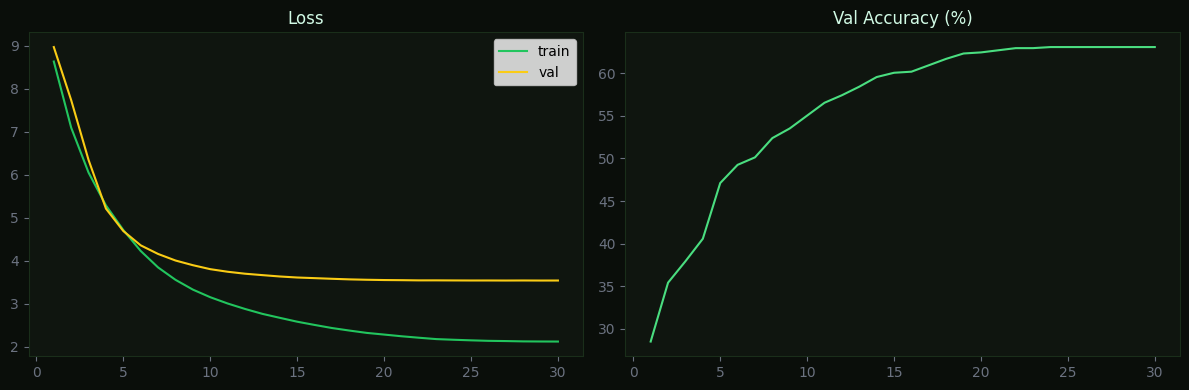

In [11]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 2D — Plot training curves
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

epochs_x = [h['epoch'] for h in history_log]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0a0e0a')
for ax in (ax1, ax2):
    ax.set_facecolor('#0f150f')
    ax.tick_params(colors='#6b7280')
    ax.spines[:].set_color('#1a2e1a')

ax1.plot(epochs_x, [h['train_loss'] for h in history_log], color='#22c55e', label='train')
ax1.plot(epochs_x, [h['val_loss']   for h in history_log], color='#facc15', label='val')
ax1.set_title('Loss', color='#d1fae5'); ax1.legend()

ax2.plot(epochs_x, [h['val_acc'] for h in history_log], color='#4ade80')
ax2.set_title('Val Accuracy (%)', color='#d1fae5')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 3 — Evaluate: play all 2,315 games with trained model
# ═══════════════════════════════════════════════════════════════════

model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

def model_guess(history, possible, top_k=5):
    """
    Use the model to pick the top-k candidates, then among those
    pick the one with the highest entropy (hybrid strategy).
    """
    state_vec = torch.tensor(encode_board(history), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(state_vec)[0]
    top_idxs = logits.topk(top_k).indices.cpu().tolist()
    top_words = [ALLOWED[i] for i in top_idxs]

    # Rerank top-k by entropy as a safety net
    if len(possible) <= 2:
        return possible[0]
    best, best_h = top_words[0], -1
    for w in top_words:
        h = entropy_score(w, possible)
        if h > best_h:
            best_h, best = h, w
    return best

results = []
for answer in tqdm(ANSWERS, desc='Evaluating'):
    possible = list(ANSWERS)
    history  = []
    solved   = False
    for turn in range(1, 7):
        guess = OPENING_GUESS if turn == 1 else model_guess(history, possible)
        pattern = get_pattern(guess, answer)
        if pattern == WIN_PATTERN:
            results.append(turn)
            solved = True
            break
        history.append((guess, pattern))
        possible = filter_words(possible, guess, pattern)
    if not solved:
        results.append(-1)

wins = [r for r in results if r > 0]
print(f'\n=== EVALUATION ===')
print(f'Win rate  : {len(wins)/len(results)*100:.1f}%')
print(f'Avg turns : {sum(wins)/len(wins):.3f}')
print(f'Distribution:')
for k, v in sorted(Counter(results).items()):
    label = f'{k} turns' if k > 0 else 'FAILED'
    print(f'  {label:8}: {v:4}  {"█" * (v // 5)}')

Evaluating:   0%|          | 0/2315 [00:00<?, ?it/s]


=== EVALUATION ===
Win rate  : 100.0%
Avg turns : 3.460
Distribution:
  1 turns :    1  
  2 turns :   59  ███████████
  3 turns : 1188  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  4 turns : 1010  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  5 turns :   56  ███████████
  6 turns :    1  


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 4 — Save + Push to Hugging Face Hub
# ═══════════════════════════════════════════════════════════════════
# First: create a free account at huggingface.co
# Then:  Settings → Access Tokens → New token (write permission)
# Paste your token below (or use the Colab secrets manager)

from huggingface_hub import HfApi, login

HF_TOKEN   = ''   # ← paste your token
HF_REPO_ID = ''  # ← e.g. jean/wordle-solver

login(token=HF_TOKEN)
api = HfApi()

# Create repo if it doesn't exist
api.create_repo(repo_id=HF_REPO_ID, exist_ok=True)

# Save everything the app needs
import json

# 1. Model weights
torch.save(model.state_dict(), 'model_weights.pt')

# 2. Model config (so we can reconstruct WordleNet)
config = {
    'input_dim': INPUT_DIM,
    'hidden': 512,
    'output_dim': OUTPUT_DIM,
    'dropout': 0.3,
    'opening_guess': OPENING_GUESS,
    'num_answers': len(ANSWERS),
    'num_allowed': len(ALLOWED),
}
with open('config.json', 'w') as f:
    json.dump(config, f, indent=2)

# 3. Word lists
with open('answers.json', 'w') as f:
    json.dump(ANSWERS, f)
with open('allowed.json', 'w') as f:
    json.dump(ALLOWED, f)

# Upload all files
for fname in ['model_weights.pt', 'config.json', 'answers.json', 'allowed.json', 'training_curves.png']:
    api.upload_file(path_or_fileobj=fname, path_in_repo=fname, repo_id=HF_REPO_ID)
    print(f'Uploaded {fname}')

print(f'\n✅ Model live at: https://huggingface.co/{HF_REPO_ID}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  model_weights.pt            :   4%|3         |  577kB / 15.7MB            

Uploaded model_weights.pt
Uploaded config.json
Uploaded answers.json
Uploaded allowed.json
Uploaded training_curves.png

✅ Model live at: https://huggingface.co/sato2ru/wordle-solver


In [17]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 5 — Gradio app for HF Spaces
# ═══════════════════════════════════════════════════════════════════
# Instructions:
#   1. Go to huggingface.co/spaces → Create Space
#   2. Choose SDK: Gradio
#   3. Create a file called app.py and paste the code below
#   4. Also add a requirements.txt with: torch gradio huggingface_hub
#
# The code is saved to app.py here too so you can download it.
app_code = '''import json, math, torch, gradio as gr
from collections import Counter
import numpy as np
from huggingface_hub import hf_hub_download
import torch.nn as nn

REPO_ID = "sato2ru/wordle-solver"

config  = json.load(open(hf_hub_download(REPO_ID, "config.json")))
ANSWERS = json.load(open(hf_hub_download(REPO_ID, "answers.json")))
ALLOWED = json.load(open(hf_hub_download(REPO_ID, "allowed.json")))
WORD2IDX = {w: i for i, w in enumerate(ALLOWED)}
LETTERS  = "abcdefghijklmnopqrstuvwxyz"
L2I = {c: i for i, c in enumerate(LETTERS)}
INPUT_DIM  = config["input_dim"]
OUTPUT_DIM = config["output_dim"]
OPENING    = config["opening_guess"]
WIN_PATTERN = (2,2,2,2,2)

class WordleNet(nn.Module):
    def __init__(self):
        super().__init__()
        h = config["hidden"]
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(h, h),         nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(h, 256),       nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, OUTPUT_DIM)
        )
    def forward(self, x): return self.net(x)

model = WordleNet()
model.load_state_dict(torch.load(hf_hub_download(REPO_ID, "model_weights.pt"), map_location="cpu"))
model.eval()

def get_pattern(guess, answer):
    pattern = [0]*5
    counts = Counter(answer)
    for i in range(5):
        if guess[i] == answer[i]:
            pattern[i] = 2
            counts[guess[i]] -= 1
    for i in range(5):
        if pattern[i] == 0 and counts.get(guess[i], 0) > 0:
            pattern[i] = 1
            counts[guess[i]] -= 1
    return tuple(pattern)

def filter_words(words, guess, pattern):
    return [w for w in words if get_pattern(guess, w) == pattern]

def entropy_score(guess, possible):
    buckets = Counter(get_pattern(guess, w) for w in possible)
    n = len(possible)
    return sum(-(c/n)*math.log2(c/n) for c in buckets.values())

def encode_board(history):
    vec = np.zeros(INPUT_DIM, dtype=np.float32)
    for word, pattern in history:
        for pos, (letter, state) in enumerate(zip(word, pattern)):
            vec[L2I[letter]*15 + pos*3 + state] = 1.0
    return vec

def model_suggest(history, possible):
    if len(possible) == 1:
        return possible[0]
    if not history:
        return OPENING
    state = torch.tensor(encode_board(history)).unsqueeze(0)
    with torch.no_grad():
        logits = model(state)[0]
    top5 = [ALLOWED[i] for i in logits.topk(5).indices.tolist()]
    return max(top5, key=lambda w: entropy_score(w, possible))

def render_board(history):
    colours = {0: "⬜", 1: "🟨", 2: "🟩"}
    rows = []
    for word, pattern in history:
        tiles = "  ".join(colours[s] + c.upper() for c, s in zip(word, pattern))
        rows.append(tiles)
    return "\\n".join(rows) if rows else "(no guesses yet)"

def process_guess(guess_input, pattern_input, state):
    if state["done"]:
        return render_board(state["history"]), "Game over — press Reset", state

    guess = guess_input.strip().lower()
    if len(guess) != 5:
        return render_board(state["history"]), "Word must be 5 letters", state
    if len(pattern_input) != 5 or not all(c in "012" for c in pattern_input):
        return render_board(state["history"]), "Pattern must be 5 digits (0/1/2)", state

    pattern = tuple(int(c) for c in pattern_input)
    state["history"].append((guess, pattern))

    if pattern == WIN_PATTERN:
        state["done"] = True
        turns = len(state["history"])
        return render_board(state["history"]), f"Solved in {turns} turns!", state

    state["possible"] = filter_words(state["possible"], guess, pattern)

    if not state["possible"]:
        state["done"] = True
        return render_board(state["history"]), "No words left. Check your input.", state

    suggestion = model_suggest(state["history"], state["possible"])
    remaining = len(state["possible"])
    msg = f"Try: {suggestion.upper()}  |  {remaining} words remaining"
    return render_board(state["history"]), msg, state

def reset_game(state):
    new_state = {"possible": list(ANSWERS), "history": [], "done": False}
    return render_board([]), f"Try: {OPENING.upper()} to start", new_state

def init_state():
    return {"possible": list(ANSWERS), "history": [], "done": False}

with gr.Blocks(title="Wordle Solver", theme=gr.themes.Monochrome()) as demo:
    gr.Markdown("# Wordle Solver")
    gr.Markdown("Enter each guess and the colour pattern. **0** = grey  **1** = yellow  **2** = green")

    state    = gr.State(init_state())
    board    = gr.Textbox(label="Board", lines=8, interactive=False)
    message  = gr.Markdown(f"Try: **{OPENING.upper()}** to start")

    with gr.Row():
        guess_box   = gr.Textbox(label="Your guess", placeholder="crane", max_lines=1)
        pattern_box = gr.Textbox(label="Pattern", placeholder="00000", max_lines=1)

    with gr.Row():
        submit_btn = gr.Button("Submit", variant="primary")
        reset_btn  = gr.Button("Reset")

    submit_btn.click(process_guess, [guess_box, pattern_box, state], [board, message, state])
    reset_btn.click(reset_game, [state], [board, message, state])

demo.launch()
'''

with open('app.py', 'w') as f:
    f.write(app_code)

with open('requirements.txt', 'w') as f:
    f.write('torch\ngradio\nhuggingface_hub\nnumpy\n')

# Also upload to HF repo so the space can use it
api.upload_file(path_or_fileobj='app.py',          path_in_repo='app.py',          repo_id=HF_REPO_ID)
api.upload_file(path_or_fileobj='requirements.txt', path_in_repo='requirements.txt', repo_id=HF_REPO_ID)

print('✅ app.py and requirements.txt saved and uploaded!')
print('\n📋 Next steps:')
print('  1. Go to huggingface.co/spaces → New Space')
print('  2. Link it to your model repo:', HF_REPO_ID)
print('  3. Set SDK = Gradio, Python 3.10')
print('  4. The app.py is already in your repo — Space will auto-build!')

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded! Check https://huggingface.co/spaces/sato2ru/wordle
